In [ ]:
# Install library yang diperlukan
!pip install optuna scikit-learn joblib pandas numpy matplotlib seaborn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 17.8 MB/s eta 0:00:00


In [ ]:
# ============================================================
# Import semua library
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json
import joblib

import optuna
from optuna.samplers import TPESampler

from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

from google.colab import files

# Konfigurasi
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

import sklearn
print('✅ Library berhasil diimport.')
print(f'   scikit-learn : {sklearn.__version__}')
print(f'   optuna       : {optuna.__version__}')
print(f'   joblib       : {joblib.__version__}')

✅ Library berhasil diimport.
   scikit-learn : 1.6.1
   optuna       : 4.9.0
   joblib       : 1.5.3


In [ ]:
# ============================================================
# Upload file CSV dari perangkat lokal
# ============================================================
print('Silakan upload file CSV dataset saham Anda...')
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print(f'\n✅ File "{filename}" berhasil diupload.')

Silakan upload file CSV dataset saham Anda...


Saving bbca_data.csv to bbca_data (1).csv

✅ File "bbca_data (1).csv" berhasil diupload.


In [ ]:
# ============================================================
# Baca CSV, set Date sebagai index, urutkan ascending
# ============================================================
df = pd.read_csv(filename, parse_dates=['Date'], index_col='Date')
df = df.sort_index(ascending=True)

# Validasi kolom
required_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
missing_cols  = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f'Kolom berikut tidak ditemukan dalam dataset: {missing_cols}')

print('✅ Dataset berhasil dimuat.')
print(f'   Baris   : {len(df):,}')
print(f'   Periode : {df.index.min().date()}  s.d.  {df.index.max().date()}')
print(f'   Kolom   : {list(df.columns)}')
df.head(10)

✅ Dataset berhasil dimuat.
   Baris   : 2,466
   Periode : 2016-01-04  s.d.  2025-12-30
   Kolom   : ['Close', 'High', 'Low', 'Open', 'Volume']


,Close,High,Low,Open,Volume
Date,,,,,
2016-01-04,2180.4744,2213.4494,2168.1087,2172.2306,77479500
2016-01-05,2205.2056,2234.0587,2176.3524,2176.3524,96609000
2016-01-06,2176.3528,2225.8153,2176.3528,2196.9622,105370000
2016-01-07,2143.3774,2168.1087,2143.3774,2159.8650,146746500
2016-01-08,2143.3774,2159.8650,2135.1337,2135.1337,125820000
2016-01-11,2102.1587,2139.2556,2102.1587,2135.1337,75952000
2016-01-12,2159.8655,2180.4749,2126.8904,2126.8904,86093500
2016-01-13,2172.2305,2192.8399,2168.1086,2180.4742,76587000
2016-01-14,2147.4995,2168.1089,2139.2558,2143.3776,119213500


In [ ]:
# ============================================================
# Statistik deskriptif
# ============================================================
print('=== Statistik Deskriptif ===')
display(df[required_cols].describe())

=== Statistik Deskriptif ===


,Open,High,Low,Close,Volume
count,2466.0000,2466.0000,2466.0000,2466.0000,2466.0000
mean,5870.4435,5922.3214,5817.6769,5869.1989,86984114.3958
std,2319.4919,2339.1170,2300.9204,2318.9172,61795162.6052
min,2102.5891,2131.6763,2098.4341,2102.1587,0.0000
25%,3940.4147,3962.3615,3902.1810,3936.1587,55207950.0000
50%,5635.1468,5686.4418,5557.8507,5622.1274,75014500.0000
75%,8094.3760,8173.2550,8017.2971,8074.2190,103083375.0000
max,10453.0463,10500.9971,10333.1719,10500.9971,1062861500.0000


In [ ]:
# ============================================================
# Cek tipe data & missing value
# ============================================================
print('=== Info Dataset ===')
df.info()
print('\n=== Jumlah Missing Value per Kolom ===')
print(df[required_cols].isnull().sum())

=== Info Dataset ===
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2466 entries, 2016-01-04 to 2025-12-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2466 non-null   float64
 1   High    2466 non-null   float64
 2   Low     2466 non-null   float64
 3   Open    2466 non-null   float64
 4   Volume  2466 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 115.6 KB

=== Jumlah Missing Value per Kolom ===
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


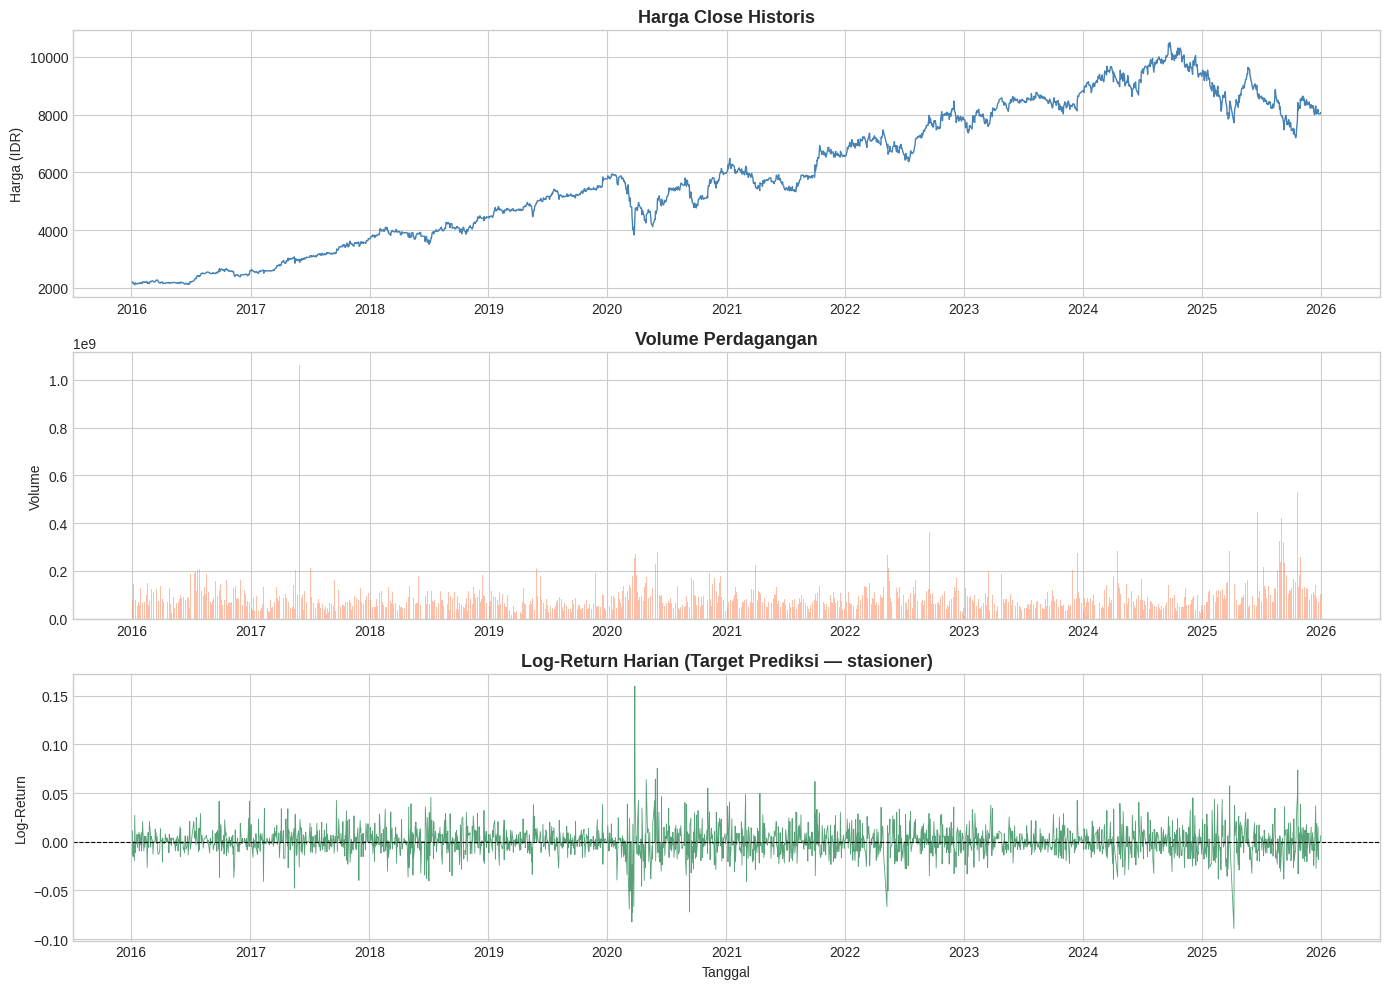

✅ Grafik EDA disimpan.


In [ ]:
# ============================================================
# Visualisasi historis: Close, Volume, dan log-return
# ============================================================
log_ret = np.log(df['Close'] / df['Close'].shift(1)).dropna()

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(df.index, df['Close'], color='steelblue', linewidth=1)
axes[0].set_title('Harga Close Historis', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Harga (IDR)')

axes[1].bar(df.index, df['Volume'], color='coral', alpha=0.5, width=1)
axes[1].set_title('Volume Perdagangan', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Volume')

axes[2].plot(log_ret.index, log_ret, color='seagreen', linewidth=0.6, alpha=0.8)
axes[2].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[2].set_title('Log-Return Harian (Target Prediksi — stasioner)',
                   fontsize=13, fontweight='bold')
axes[2].set_ylabel('Log-Return')
axes[2].set_xlabel('Tanggal')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik EDA disimpan.')

In [ ]:
# ============================================================
# Tangani missing value dengan forward fill
# ============================================================
before = df[required_cols].isnull().sum().sum()
df = df.ffill().bfill()
after  = df[required_cols].isnull().sum().sum()
print(f'Missing value sebelum : {before}')
print(f'Missing value sesudah : {after}')
print('✅ Penanganan missing value selesai.')

Missing value sebelum : 0
Missing value sesudah : 0
✅ Penanganan missing value selesai.


In [ ]:
# ============================================================
# Konfigurasi global
# ============================================================
FEATURE_COLS        = ['Open', 'High', 'Low', 'Close', 'Volume']
LOOKBACK_CANDIDATES = [1, 3, 5, 10, 20, 30]

print(f'Fitur dasar       : {FEATURE_COLS}')
print(f'Kandidat lookback : {LOOKBACK_CANDIDATES}')
print('Target prediksi   : log-return Close hari berikutnya (T+1)')

Fitur dasar       : ['Open', 'High', 'Low', 'Close', 'Volume']
Kandidat lookback : [1, 3, 5, 10, 20, 30]
Target prediksi   : log-return Close hari berikutnya (T+1)


In [ ]:
# ============================================================
# Fungsi: Buat lag features berbasis log-return
#
# Transformasi fitur:
#   - Open/High/Low/Close → log-return: ln(P_t / P_{t-1})
#   - Volume              → log1p(Volume) untuk mengurangi skewness
#
# Target:
#   target[t] = ln(Close[t+1] / Close[t])  →  shift(-1)
#
# Close_t (harga hari ini) disimpan terpisah untuk rekonstruksi,
# BUKAN sebagai fitur, sehingga tidak ada data leakage.
# ============================================================
def create_lag_features(df, feature_cols, lookback):
    """
    Membuat lag features log-return untuk SVR.

    Parameters
    ----------
    df           : DataFrame (sudah diurutkan ascending, sudah clean)
    feature_cols : list kolom OHLCV
    lookback     : int, jumlah hari lag

    Returns
    -------
    X             : ndarray (n_samples, n_features)
    y_logret      : ndarray target log-return (n_samples,)
    close_t       : ndarray Close[t] untuk rekonstruksi harga (n_samples,)
    feature_names : list nama fitur
    """
    price_cols = ['Open', 'High', 'Low', 'Close']

    # Transformasi ke log-return / log-scale
    transformed = {}
    for col in price_cols:
        transformed[f'{col}_logret'] = np.log(df[col] / df[col].shift(1))
    transformed['Volume_log'] = np.log1p(df['Volume'])
    tdf = pd.DataFrame(transformed, index=df.index)

    feat_cols_t = list(tdf.columns)

    # Buat lag features
    lag_frames, col_names = [], []
    for lag in range(1, lookback + 1):
        shifted = tdf.shift(lag)
        shifted.columns = [f'{c}_lag{lag}' for c in feat_cols_t]
        lag_frames.append(shifted)
        col_names.extend(shifted.columns.tolist())

    lag_df = pd.concat(lag_frames, axis=1)

    # Target: log-return Close hari berikutnya
    lag_df['target_logret'] = np.log(df['Close'] / df['Close'].shift(1)).shift(-1)

    # Close[t] untuk rekonstruksi — bukan fitur
    lag_df['Close_t'] = df['Close']

    lag_df = lag_df.dropna()

    X         = lag_df[col_names].values
    y_logret  = lag_df['target_logret'].values
    close_t   = lag_df['Close_t'].values

    return X, y_logret, close_t, col_names


# ============================================================
# Fungsi: Split train/test kronologis (tanpa shuffle)
# ============================================================
def timeseries_split(X, y, close_t, test_ratio=0.20):
    n     = len(X)
    split = int(n * (1 - test_ratio))
    return (X[:split], X[split:],
            y[:split], y[split:],
            close_t[:split], close_t[split:])


# ============================================================
# Fungsi: Hitung metrik evaluasi pada skala harga asli (IDR)
# ============================================================
def compute_metrics(y_logret_true, y_logret_pred, close_t):
    """
    Konversi log-return → harga absolut, lalu hitung RMSE / MAE / R².
    """
    y_true_p = close_t * np.exp(y_logret_true)
    y_pred_p = close_t * np.exp(y_logret_pred)
    rmse = np.sqrt(mean_squared_error(y_true_p, y_pred_p))
    mae  = mean_absolute_error(y_true_p, y_pred_p)
    r2   = r2_score(y_true_p, y_pred_p)
    return rmse, mae, r2, y_true_p, y_pred_p


print('✅ Fungsi helper berhasil didefinisikan.')

✅ Fungsi helper berhasil didefinisikan.


In [ ]:
# ============================================================
# Evaluasi setiap lookback menggunakan SVR dengan parameter default
# Pilih lookback dengan RMSE test terkecil
# MinMaxScaler di-fit HANYA pada data training
# ============================================================
print('=' * 62)
print(f'{"Lookback":>10} | {"RMSE (IDR)":>12} | {"MAE (IDR)":>12} | {"R²":>8} | {"n_test":>7}')
print('-' * 62)

lookback_results = []

for lb in LOOKBACK_CANDIDATES:
    X_all, y_all, c_all, feat_names = create_lag_features(df, FEATURE_COLS, lb)
    X_tr, X_te, y_tr, y_te, c_tr, c_te = timeseries_split(X_all, y_all, c_all)

    # Scaling fitur — fit HANYA pada training, transform keduanya
    # y (log-return) tidak di-scale; sudah mendekati distribusi normal di sekitar 0
    scaler = MinMaxScaler()
    X_tr_sc = scaler.fit_transform(X_tr)
    X_te_sc = scaler.transform(X_te)

    # SVR dengan hyperparameter default yang reasonable
    svr = SVR(kernel='rbf', C=10.0, epsilon=0.01, gamma='scale')
    svr.fit(X_tr_sc, y_tr)

    y_pred   = svr.predict(X_te_sc)
    rmse, mae, r2, _, _ = compute_metrics(y_te, y_pred, c_te)

    lookback_results.append({
        'lookback'    : lb,
        'rmse'        : rmse,
        'mae'         : mae,
        'r2'          : r2,
        'n_train'     : len(X_tr),
        'n_test'      : len(X_te),
        'feat_names'  : feat_names
    })
    print(f'{lb:>10} | {rmse:>12.2f} | {mae:>12.2f} | {r2:>8.4f} | {len(X_te):>7}')

print('=' * 62)

best_lb_row   = min(lookback_results, key=lambda x: x['rmse'])
BEST_LOOKBACK = best_lb_row['lookback']
print(f'\n✅ Lookback terbaik : {BEST_LOOKBACK} hari')
print(f'   RMSE             : {best_lb_row["rmse"]:.4f} IDR')
print(f'   R²               : {best_lb_row["r2"]:.4f}')

  Lookback |   RMSE (IDR) |    MAE (IDR) |       R² |  n_test
--------------------------------------------------------------
         1 |       157.92 |       111.60 |   0.9503 |     493
         3 |       158.50 |       116.12 |   0.9499 |     493
         5 |       168.12 |       125.07 |   0.9437 |     492
        10 |       181.04 |       132.09 |   0.9347 |     491
        20 |       182.57 |       138.76 |   0.9337 |     489
        30 |       185.21 |       141.30 |   0.9317 |     487

✅ Lookback terbaik : 1 hari
   RMSE             : 157.9178 IDR
   R²               : 0.9503


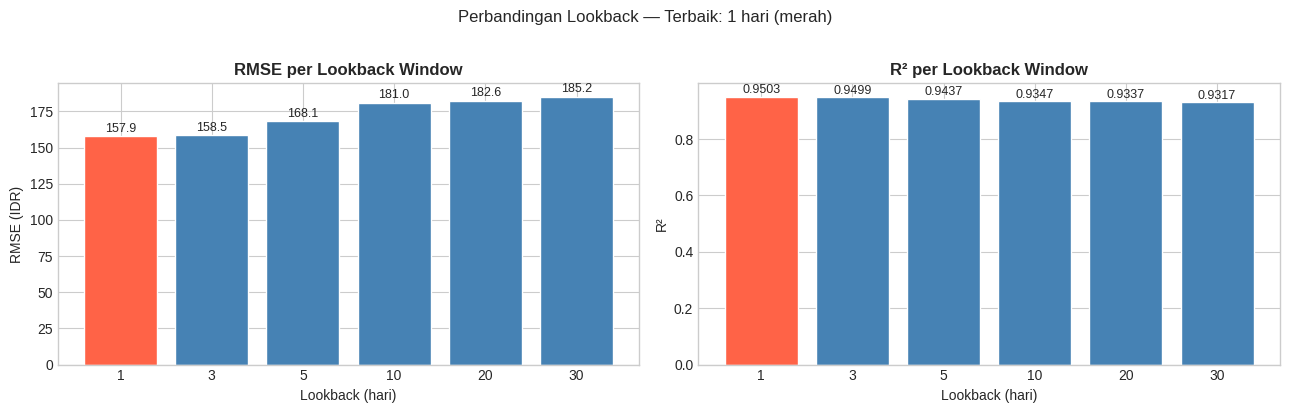

In [ ]:
# ============================================================
# Visualisasi perbandingan RMSE & R² per lookback
# ============================================================
lb_vals   = [r['lookback'] for r in lookback_results]
rmse_vals = [r['rmse']     for r in lookback_results]
r2_vals   = [r['r2']       for r in lookback_results]
colors    = ['tomato' if lb == BEST_LOOKBACK else 'steelblue' for lb in lb_vals]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

bars = axes[0].bar([str(lb) for lb in lb_vals], rmse_vals, color=colors, edgecolor='white')
for bar, val in zip(bars, rmse_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + max(rmse_vals)*0.005,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=9)
axes[0].set_title('RMSE per Lookback Window', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Lookback (hari)')
axes[0].set_ylabel('RMSE (IDR)')

bars2 = axes[1].bar([str(lb) for lb in lb_vals], r2_vals, color=colors, edgecolor='white')
for bar, val in zip(bars2, r2_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.001,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9)
axes[1].set_title('R² per Lookback Window', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Lookback (hari)')
axes[1].set_ylabel('R²')

plt.suptitle(f'Perbandingan Lookback — Terbaik: {BEST_LOOKBACK} hari (merah)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('lookback_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# Buat dataset final menggunakan lookback terbaik
# ============================================================
X_all, y_all, c_all, FEATURE_NAMES = create_lag_features(df, FEATURE_COLS, BEST_LOOKBACK)
X_train, X_test, y_train, y_test, c_train, c_test = timeseries_split(X_all, y_all, c_all)

# MinMaxScaler: fit HANYA pada training, transform training & test
scaler_X = MinMaxScaler()
X_train_sc = scaler_X.fit_transform(X_train)
X_test_sc  = scaler_X.transform(X_test)

print(f'Lookback terbaik  : {BEST_LOOKBACK} hari')
print(f'Jumlah fitur      : {X_train.shape[1]}')
print(f'Ukuran training   : {X_train.shape[0]:,} sampel '
      f'({X_train.shape[0]/(X_train.shape[0]+X_test.shape[0])*100:.1f}%)')
print(f'Ukuran testing    : {X_test.shape[0]:,} sampel '
      f'({X_test.shape[0]/(X_train.shape[0]+X_test.shape[0])*100:.1f}%)')
print(f'y_train range     : [{y_train.min():.5f}, {y_train.max():.5f}]')
print(f'y_test  range     : [{y_test.min():.5f}, {y_test.max():.5f}]')
print('✅ Tidak ada out-of-range issue (log-return stasioner).')

Lookback terbaik  : 1 hari
Jumlah fitur      : 5
Ukuran training   : 1,970 sampel (80.0%)
Ukuran testing    : 493 sampel (20.0%)
y_train range     : [-0.08244, 0.15985]
y_test  range     : [-0.08915, 0.07343]
✅ Tidak ada out-of-range issue (log-return stasioner).


In [ ]:
# ============================================================
# Objective function untuk Optuna
#
# Parameter yang di-tune:
#   C       : regularisasi (semakin besar → margin lebih sempit, lebih fit)
#   epsilon : lebar tube (toleransi error yang tidak dikenai penalti)
#   gamma   : 'scale' atau nilai float (lebar kernel RBF)
#
# Metrik optimasi: RMSE pada skala harga asli (IDR)
# ============================================================
def objective(trial):
    C       = trial.suggest_float('C',       0.1,  1000.0, log=True)
    epsilon = trial.suggest_float('epsilon', 1e-4, 0.1,    log=True)
    gamma   = trial.suggest_categorical('gamma', ['scale', 'auto'])

    # Jika gamma bukan string, uji juga nilai float
    use_float_gamma = trial.suggest_categorical('use_float_gamma', [True, False])
    if use_float_gamma:
        gamma = trial.suggest_float('gamma_val', 1e-4, 1.0, log=True)

    svr = SVR(kernel='rbf', C=C, epsilon=epsilon, gamma=gamma)
    svr.fit(X_train_sc, y_train)

    y_pred          = svr.predict(X_test_sc)
    rmse, _, _, _, _ = compute_metrics(y_test, y_pred, c_test)
    return rmse


# ============================================================
# Jalankan Optuna — minimal 50 trial
# TPESampler = Tree-structured Parzen Estimator (default Optuna)
# ============================================================
N_TRIALS = 50

print(f'Memulai Optuna hyperparameter search ({N_TRIALS} trial)...')
print('Parameter: C, epsilon, gamma (kernel=rbf)')
print()

study = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=RANDOM_SEED),
    study_name='svr_stock_logret'
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f'\n✅ Optuna selesai.')
print(f'   RMSE terbaik (IDR) : {study.best_value:.4f}')
print('   Parameter terbaik  :')
for k, v in study.best_params.items():
    print(f'     {k:<22}: {v}')

Memulai Optuna hyperparameter search (50 trial)...
Parameter: C, epsilon, gamma (kernel=rbf)



  0%|          | 0/50 [00:00<?, ?it/s]


✅ Optuna selesai.
   RMSE terbaik (IDR) : 140.8385
   Parameter terbaik  :
     C                     : 1.5682118350953562
     epsilon               : 0.00010192300549111155
     gamma                 : auto
     use_float_gamma       : False


In [ ]:
# ============================================================
# Rekonstruksi parameter SVR final dari hasil Optuna
# (gabungkan hasil use_float_gamma)
# ============================================================
bp = study.best_params

BEST_C       = bp['C']
BEST_EPSILON = bp['epsilon']

if bp.get('use_float_gamma', False) and 'gamma_val' in bp:
    BEST_GAMMA = bp['gamma_val']
else:
    BEST_GAMMA = bp.get('gamma', 'scale')

print(f'Parameter SVR final:')
print(f'  kernel  : rbf')
print(f'  C       : {BEST_C:.6f}')
print(f'  epsilon : {BEST_EPSILON:.6f}')
print(f'  gamma   : {BEST_GAMMA}')

Parameter SVR final:
  kernel  : rbf
  C       : 1.568212
  epsilon : 0.000102
  gamma   : auto


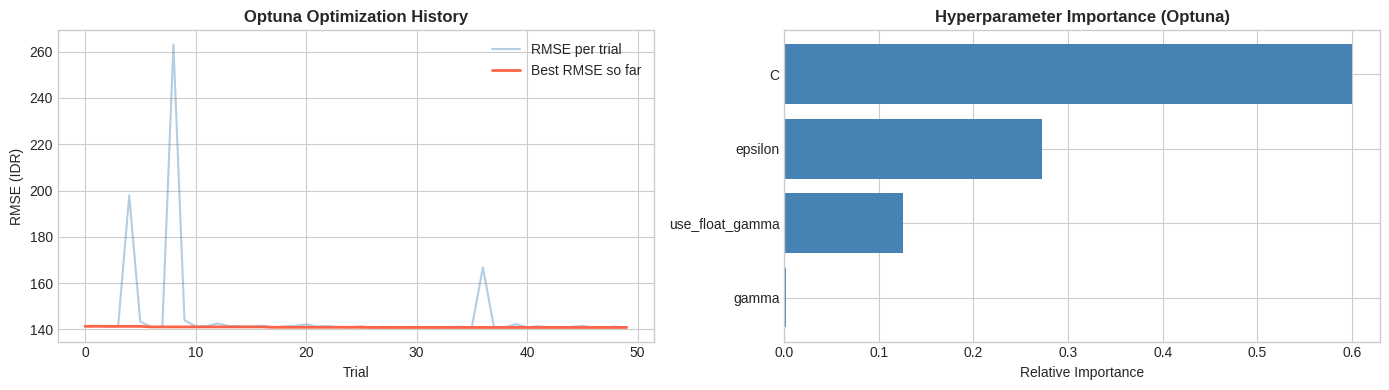

In [ ]:
# ============================================================
# Visualisasi history Optuna
# ============================================================
trial_vals  = [t.value for t in study.trials]
best_so_far = [min(trial_vals[:i+1]) for i in range(len(trial_vals))]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(trial_vals, alpha=0.4, color='steelblue', label='RMSE per trial')
axes[0].plot(best_so_far, color='tomato', linewidth=2, label='Best RMSE so far')
axes[0].set_title('Optuna Optimization History', fontweight='bold')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('RMSE (IDR)')
axes[0].legend()

try:
    importances = optuna.importance.get_param_importances(study)
    imp_keys = list(importances.keys())
    imp_vals = list(importances.values())
    axes[1].barh(imp_keys[::-1], imp_vals[::-1], color='steelblue')
    axes[1].set_title('Hyperparameter Importance (Optuna)', fontweight='bold')
    axes[1].set_xlabel('Relative Importance')
except Exception:
    axes[1].text(0.5, 0.5, 'Importance tidak tersedia\n(perlu lebih banyak trial)',
                 ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig('optuna_history.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# Latih SVR final dengan hyperparameter terbaik dari Optuna
# ============================================================
best_svr = SVR(
    kernel  = 'rbf',
    C       = BEST_C,
    epsilon = BEST_EPSILON,
    gamma   = BEST_GAMMA
)
best_svr.fit(X_train_sc, y_train)

print('✅ Model SVR terbaik selesai dilatih.')
print(f'   Jumlah support vector : {best_svr.n_support_[0]:,}')
print(f'   Rasio support vector  : {best_svr.n_support_[0]/len(X_train)*100:.1f}%')

✅ Model SVR terbaik selesai dilatih.
   Jumlah support vector : 1,910
   Rasio support vector  : 97.0%


In [ ]:
# ============================================================
# Prediksi log-return → rekonstruksi harga absolut → hitung metrik
# ============================================================
y_train_pred_lr = best_svr.predict(X_train_sc)
y_test_pred_lr  = best_svr.predict(X_test_sc)

train_rmse, train_mae, train_r2, y_train_true_p, y_train_pred_p = \
    compute_metrics(y_train, y_train_pred_lr, c_train)
test_rmse, test_mae, test_r2, y_test_true_p, y_test_pred_p = \
    compute_metrics(y_test, y_test_pred_lr, c_test)

print('=== Evaluasi Model SVR (skala harga asli, IDR) ===')
print(f'  [Training] RMSE: {train_rmse:>10.4f}  |  MAE: {train_mae:>10.4f}  |  R²: {train_r2:.4f}')
print(f'  [Testing ] RMSE: {test_rmse:>10.4f}  |  MAE: {test_mae:>10.4f}  |  R²: {test_r2:.4f}')
print(f'\n  Rasio RMSE Test/Train : {test_rmse/train_rmse:.3f}  (mendekati 1 = seimbang)')

eval_df = pd.DataFrame({
    'Metrik'   : ['RMSE (IDR)', 'MAE (IDR)', 'R²'],
    'Training' : [train_rmse, train_mae, train_r2],
    'Testing'  : [test_rmse,  test_mae,  test_r2]
})
display(eval_df.set_index('Metrik'))

=== Evaluasi Model SVR (skala harga asli, IDR) ===
  [Training] RMSE:    75.9243  |  MAE:    49.1873  |  R²: 0.9984
  [Testing ] RMSE:   140.8385  |  MAE:   105.5259  |  R²: 0.9605

  Rasio RMSE Test/Train : 1.855  (mendekati 1 = seimbang)


,Training,Testing
Metrik,,
RMSE (IDR),75.9243,140.8385
MAE (IDR),49.1873,105.5259
R²,0.9984,0.9605


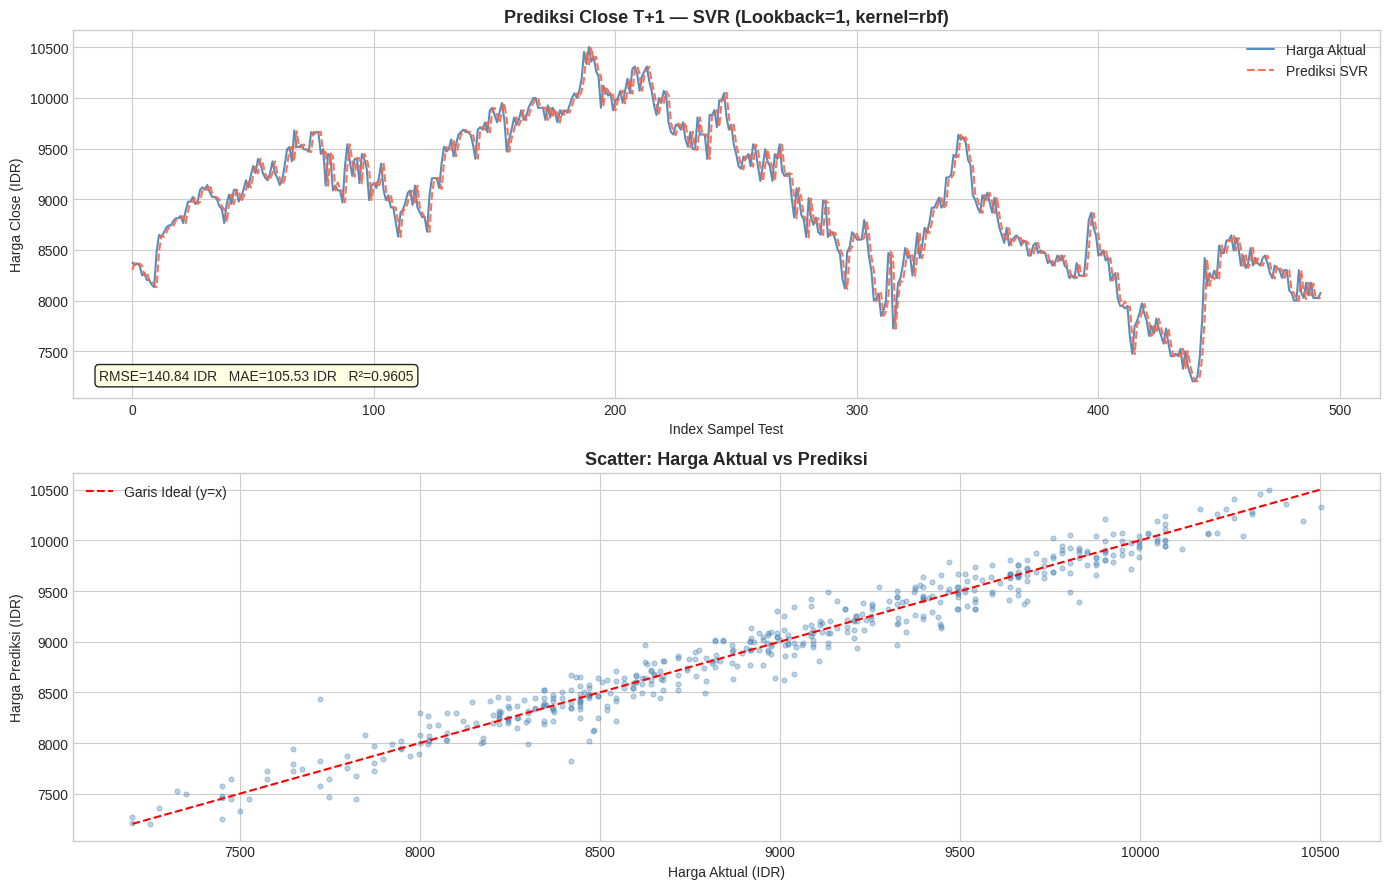

✅ Grafik prediksi disimpan.


In [ ]:
# ============================================================
# Visualisasi 1: Actual vs Predicted (time series + scatter)
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

idx = range(len(y_test_true_p))
axes[0].plot(idx, y_test_true_p, color='steelblue', linewidth=1.5,
             label='Harga Aktual', alpha=0.9)
axes[0].plot(idx, y_test_pred_p, color='tomato', linewidth=1.5,
             linestyle='--', label='Prediksi SVR', alpha=0.9)
axes[0].set_title(f'Prediksi Close T+1 — SVR (Lookback={BEST_LOOKBACK}, kernel=rbf)',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Index Sampel Test')
axes[0].set_ylabel('Harga Close (IDR)')
axes[0].legend()
axes[0].text(
    0.02, 0.05,
    f'RMSE={test_rmse:.2f} IDR   MAE={test_mae:.2f} IDR   R²={test_r2:.4f}',
    transform=axes[0].transAxes, fontsize=10,
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.85)
)

axes[1].scatter(y_test_true_p, y_test_pred_p, alpha=0.35, s=12, color='steelblue')
lo = min(y_test_true_p.min(), y_test_pred_p.min())
hi = max(y_test_true_p.max(), y_test_pred_p.max())
axes[1].plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='Garis Ideal (y=x)')
axes[1].set_title('Scatter: Harga Aktual vs Prediksi', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Harga Aktual (IDR)')
axes[1].set_ylabel('Harga Prediksi (IDR)')
axes[1].legend()

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik prediksi disimpan.')

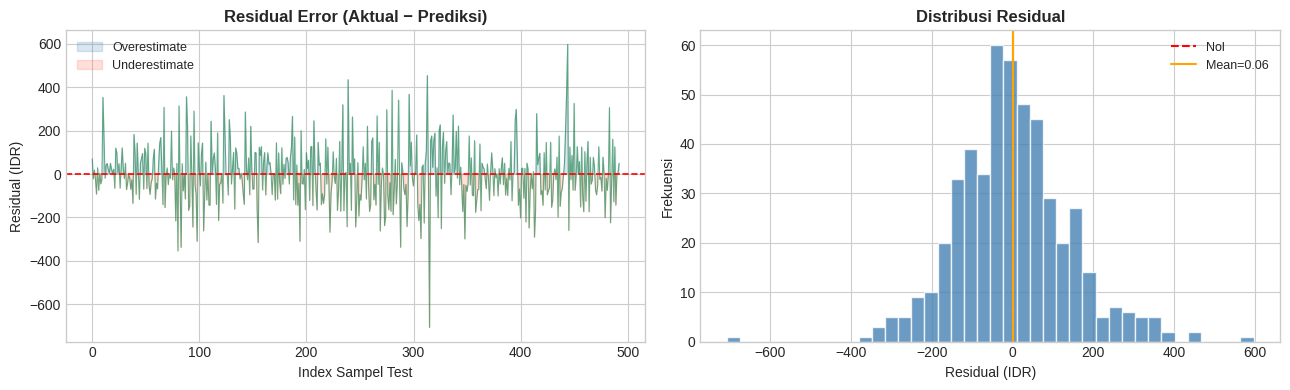

In [ ]:
# ============================================================
# Visualisasi 2: Analisis residual
# ============================================================
residuals = y_test_true_p - y_test_pred_p

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(residuals, color='seagreen', linewidth=0.8, alpha=0.7)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.2)
axes[0].fill_between(range(len(residuals)), residuals, 0,
                      where=(residuals > 0), color='steelblue', alpha=0.2, label='Overestimate')
axes[0].fill_between(range(len(residuals)), residuals, 0,
                      where=(residuals < 0), color='tomato',    alpha=0.2, label='Underestimate')
axes[0].set_title('Residual Error (Aktual − Prediksi)', fontweight='bold')
axes[0].set_xlabel('Index Sampel Test')
axes[0].set_ylabel('Residual (IDR)')
axes[0].legend(fontsize=9)

axes[1].hist(residuals, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0,               color='red',   linestyle='--', linewidth=1.5, label='Nol')
axes[1].axvline(residuals.mean(), color='orange', linestyle='-',  linewidth=1.5,
                label=f'Mean={residuals.mean():.2f}')
axes[1].set_title('Distribusi Residual', fontweight='bold')
axes[1].set_xlabel('Residual (IDR)')
axes[1].set_ylabel('Frekuensi')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

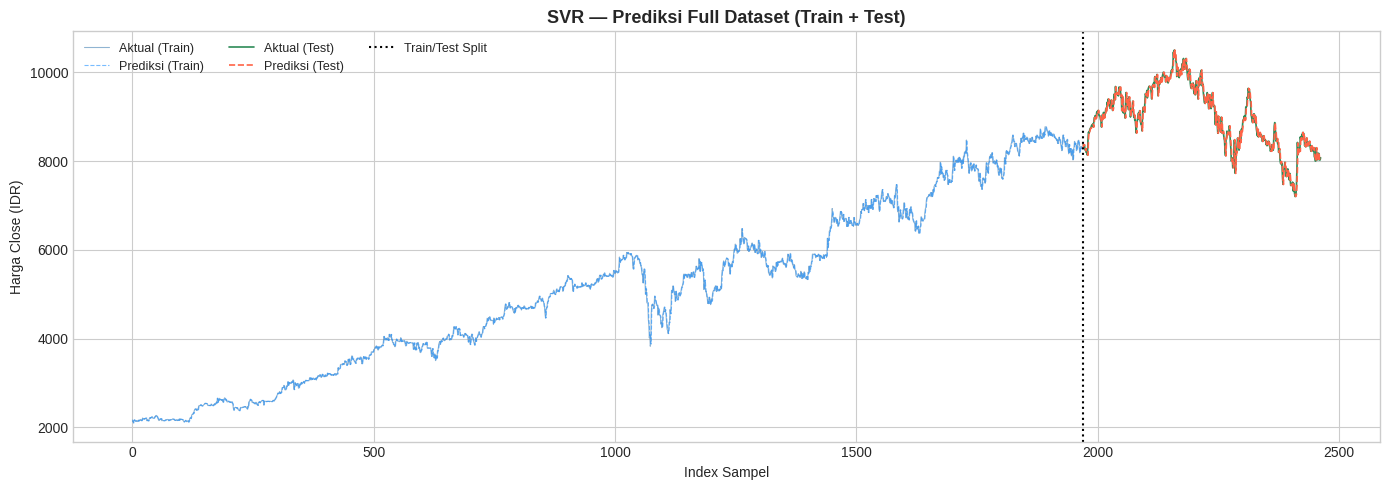

In [ ]:
# ============================================================
# Visualisasi 3: Perbandingan train vs test predictions
# ============================================================
fig, ax = plt.subplots(figsize=(14, 5))

n_tr = len(y_train_true_p)
n_te = len(y_test_true_p)

ax.plot(range(n_tr), y_train_true_p, color='steelblue',  linewidth=0.8, alpha=0.6, label='Aktual (Train)')
ax.plot(range(n_tr), y_train_pred_p, color='dodgerblue', linewidth=0.8, alpha=0.6,
        linestyle='--', label='Prediksi (Train)')
ax.plot(range(n_tr, n_tr + n_te), y_test_true_p, color='seagreen', linewidth=1.2, label='Aktual (Test)')
ax.plot(range(n_tr, n_tr + n_te), y_test_pred_p, color='tomato',   linewidth=1.2,
        linestyle='--', label='Prediksi (Test)')
ax.axvline(n_tr, color='black', linestyle=':', linewidth=1.5, label='Train/Test Split')
ax.set_title('SVR — Prediksi Full Dataset (Train + Test)', fontsize=13, fontweight='bold')
ax.set_xlabel('Index Sampel')
ax.set_ylabel('Harga Close (IDR)')
ax.legend(fontsize=9, ncol=3)

plt.tight_layout()
plt.savefig('full_prediction_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# ============================================================
# Walk-Forward Validation — Expanding Window, 5-Fold
#
# Strategi expanding window:
#   Fold 1 : train = [0 .. fold_size-1]       | val = [fold_size .. 2·fold_size-1]
#   Fold 2 : train = [0 .. 2·fold_size-1]     | val = [2·fold_size .. 3·fold_size-1]
#   ...dst.  (window training terus bertambah)
#
# MinMaxScaler di-fit ulang di SETIAP fold pada training fold
# ============================================================
N_FOLDS = 5
X_wfv, y_wfv, c_wfv, _ = create_lag_features(df, FEATURE_COLS, BEST_LOOKBACK)

fold_size   = len(X_wfv) // (N_FOLDS + 1)
wfv_results = []

print(f'Walk-Forward Validation — {N_FOLDS} Fold (Expanding Window)')
print(f'Lookback    : {BEST_LOOKBACK} hari')
print(f'Total data  : {len(X_wfv):,} sampel | Fold size: ±{fold_size:,}')
print('=' * 74)
print(f'{"Fold":>6} | {"n_train":>8} | {"n_val":>8} | {"RMSE (IDR)":>12} | {"MAE (IDR)":>12} | {"R²":>8}')
print('-' * 74)

for fold in range(1, N_FOLDS + 1):
    train_end = fold * fold_size
    val_end   = min(train_end + fold_size, len(X_wfv))

    X_tr_f = X_wfv[:train_end]
    y_tr_f = y_wfv[:train_end]
    c_tr_f = c_wfv[:train_end]
    X_vl_f = X_wfv[train_end:val_end]
    y_vl_f = y_wfv[train_end:val_end]
    c_vl_f = c_wfv[train_end:val_end]

    if len(X_vl_f) == 0:
        continue

    # Scaler baru tiap fold — fit HANYA pada training fold
    sc_f = MinMaxScaler()
    X_tr_f_sc = sc_f.fit_transform(X_tr_f)
    X_vl_f_sc = sc_f.transform(X_vl_f)

    svr_f = SVR(kernel='rbf', C=BEST_C, epsilon=BEST_EPSILON, gamma=BEST_GAMMA)
    svr_f.fit(X_tr_f_sc, y_tr_f)

    y_pred_f = svr_f.predict(X_vl_f_sc)
    rmse_f, mae_f, r2_f, _, _ = compute_metrics(y_vl_f, y_pred_f, c_vl_f)

    wfv_results.append({
        'fold'   : fold,
        'rmse'   : rmse_f,
        'mae'    : mae_f,
        'r2'     : r2_f,
        'n_train': len(X_tr_f),
        'n_val'  : len(X_vl_f)
    })
    print(f'{fold:>6} | {len(X_tr_f):>8,} | {len(X_vl_f):>8,} | '
          f'{rmse_f:>12.4f} | {mae_f:>12.4f} | {r2_f:>8.4f}')

print('=' * 74)
avg_rmse = np.mean([r['rmse'] for r in wfv_results])
avg_mae  = np.mean([r['mae']  for r in wfv_results])
avg_r2   = np.mean([r['r2']   for r in wfv_results])
std_rmse = np.std( [r['rmse'] for r in wfv_results])
std_r2   = np.std( [r['r2']   for r in wfv_results])
print(f'{"Rata-rata":>6} | {"":>8} | {"":>8} | {avg_rmse:>12.4f} | {avg_mae:>12.4f} | {avg_r2:>8.4f}')
print(f'{"Std Dev":>6}   | {"":>8} | {"":>8} | {std_rmse:>12.4f} | {"":>12} | {std_r2:>8.4f}')
print(f'\n✅ Walk-forward validation selesai.')

Walk-Forward Validation — 5 Fold (Expanding Window)
Lookback    : 1 hari
Total data  : 2,463 sampel | Fold size: ±410
  Fold |  n_train |    n_val |   RMSE (IDR) |    MAE (IDR) |       R²
--------------------------------------------------------------------------
     1 |      410 |      410 |      49.8014 |      35.1355 |   0.9845
     2 |      820 |      410 |      96.2011 |      60.5488 |   0.9421
     3 |    1,230 |      410 |      94.3877 |      68.5816 |   0.9730
     4 |    1,640 |      410 |      94.7196 |      71.1380 |   0.9722
     5 |    2,050 |      410 |     148.3239 |     112.7599 |   0.9611
Rata-rata |          |          |      96.6867 |      69.6328 |   0.9666
Std Dev   |          |          |      31.2219 |              |   0.0143

✅ Walk-forward validation selesai.


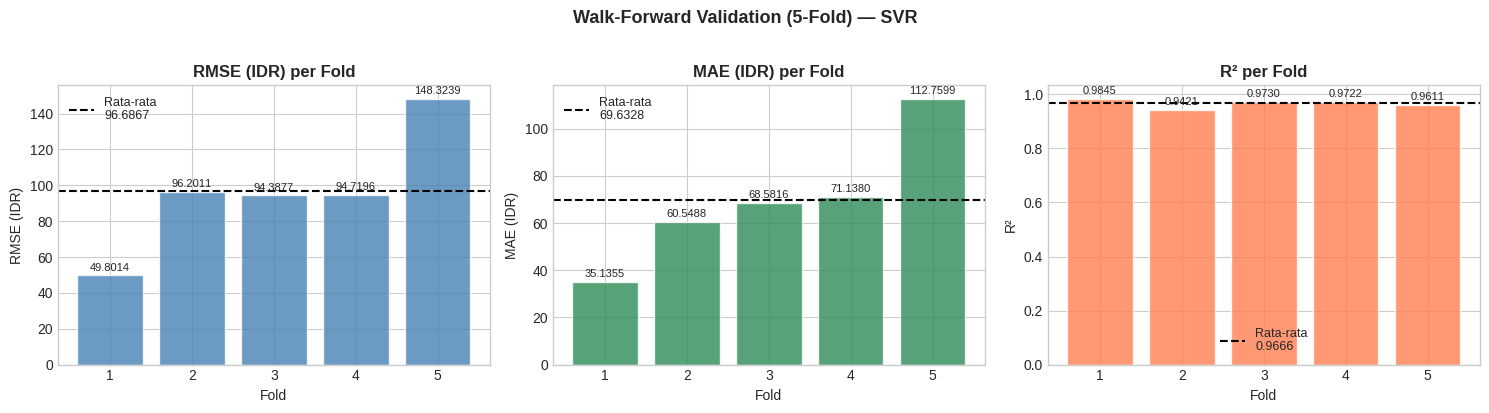

In [23]:
# ============================================================
# Visualisasi walk-forward validation
# ============================================================
folds_list = [r['fold'] for r in wfv_results]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric, label, color in zip(
    axes,
    ['rmse', 'mae', 'r2'],
    ['RMSE (IDR)', 'MAE (IDR)', 'R²'],
    ['steelblue', 'seagreen', 'coral']
):
    vals = [r[metric] for r in wfv_results]
    avg  = np.mean(vals)
    bars = ax.bar(folds_list, vals, color=color, alpha=0.8, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8)
    ax.axhline(avg, color='black', linestyle='--', linewidth=1.5,
               label=f'Rata-rata\n{avg:.4f}')
    ax.set_title(f'{label} per Fold', fontweight='bold')
    ax.set_xlabel('Fold')
    ax.set_ylabel(label)
    ax.legend(fontsize=9)
    ax.set_xticks(folds_list)

plt.suptitle('Walk-Forward Validation (5-Fold) — SVR', fontsize=13,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('walk_forward_validation.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# ============================================================
# Cetak ringkasan lengkap untuk skripsi
# ============================================================
sep  = '═' * 62
sep2 = '─' * 62

print(sep)
print('   RINGKASAN HASIL — SVR Stock Price Prediction')
print(sep)
print(f'  Dataset              : {filename}')
print(f'  Target               : Close T+1 (via log-return)')
print(f'  Kernel               : RBF')
print(sep2)
print(f'  Lookback terbaik     : {BEST_LOOKBACK} hari')
print(f'  Jumlah fitur         : {X_train.shape[1]}')
print(sep2)
print('  Hyperparameter Terbaik (Optuna):')
print(f'    C       : {BEST_C:.6f}')
print(f'    epsilon : {BEST_EPSILON:.6f}')
print(f'    gamma   : {BEST_GAMMA}')
print(sep2)
print('  Evaluasi Data Test (skala harga asli, IDR):')
print(f'    RMSE  : {test_rmse:.4f}')
print(f'    MAE   : {test_mae:.4f}')
print(f'    R²    : {test_r2:.4f}')
print(sep2)
print(f'  Walk-Forward Validation ({N_FOLDS}-fold, rata-rata):')
print(f'    RMSE  : {avg_rmse:.4f}  (±{std_rmse:.4f})')
print(f'    MAE   : {avg_mae:.4f}')
print(f'    R²    : {avg_r2:.4f}  (±{std_r2:.4f})')
print(sep)

══════════════════════════════════════════════════════════════
   RINGKASAN HASIL — SVR Stock Price Prediction
══════════════════════════════════════════════════════════════
  Dataset              : bbca_data (1).csv
  Target               : Close T+1 (via log-return)
  Kernel               : RBF
──────────────────────────────────────────────────────────────
  Lookback terbaik     : 1 hari
  Jumlah fitur         : 5
──────────────────────────────────────────────────────────────
  Hyperparameter Terbaik (Optuna):
    C       : 1.568212
    epsilon : 0.000102
    gamma   : auto
──────────────────────────────────────────────────────────────
  Evaluasi Data Test (skala harga asli, IDR):
    RMSE  : 140.8385
    MAE   : 105.5259
    R²    : 0.9605
──────────────────────────────────────────────────────────────
  Walk-Forward Validation (5-fold, rata-rata):
    RMSE  : 96.6867  (±31.2219)
    MAE   : 69.6328
    R²    : 0.9666  (±0.0143)
═══════════════════════════════════════════════════════

In [25]:
# ============================================================
# Simpan model SVR beserta scaler menggunakan joblib
#
# Struktur yang disimpan:
#   svr_model_lb{N}.pkl  → dict berisi:
#     - 'svr'    : model SVR terlatih
#     - 'scaler' : MinMaxScaler yang di-fit pada training
#     - 'params' : hyperparameter
#     - 'lookback': nilai lookback terbaik
#
# Menyimpan scaler bersama model penting agar prediksi
# pada data baru dapat dilakukan dengan benar.
# ============================================================
MODEL_PATH   = f'svr_model_lb{BEST_LOOKBACK}.pkl'
SUMMARY_PATH = f'svr_summary_lb{BEST_LOOKBACK}.json'

model_bundle = {
    'svr'      : best_svr,
    'scaler'   : scaler_X,
    'lookback' : BEST_LOOKBACK,
    'params'   : {
        'kernel' : 'rbf',
        'C'      : BEST_C,
        'epsilon': BEST_EPSILON,
        'gamma'  : BEST_GAMMA
    },
    'feature_names': FEATURE_NAMES
}
joblib.dump(model_bundle, MODEL_PATH)
print(f'✅ Model + Scaler disimpan  : {MODEL_PATH}')

# Simpan ringkasan metrik ke JSON
summary = {
    'best_lookback'   : int(BEST_LOOKBACK),
    'target_type'     : 'log_return',
    'kernel'          : 'rbf',
    'best_params'     : {
        'C'      : float(BEST_C),
        'epsilon': float(BEST_EPSILON),
        'gamma'  : str(BEST_GAMMA)
    },
    'test_metrics'    : {
        'rmse': float(test_rmse),
        'mae' : float(test_mae),
        'r2'  : float(test_r2)
    },
    'wfv_avg_metrics' : {
        'rmse'    : float(avg_rmse),
        'mae'     : float(avg_mae),
        'r2'      : float(avg_r2),
        'rmse_std': float(std_rmse),
        'r2_std'  : float(std_r2)
    },
    'wfv_fold_details': wfv_results
}
with open(SUMMARY_PATH, 'w') as f:
    json.dump(summary, f, indent=2)
print(f'✅ Ringkasan hasil disimpan  : {SUMMARY_PATH}')

# Download ke komputer lokal
files.download(MODEL_PATH)
files.download(SUMMARY_PATH)

✅ Model + Scaler disimpan  : svr_model_lb1.pkl
✅ Ringkasan hasil disimpan  : svr_summary_lb1.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
# ============================================================
# Verifikasi: Load model tersimpan & uji konsistensi prediksi
# ============================================================
bundle_loaded = joblib.load(MODEL_PATH)
svr_loaded    = bundle_loaded['svr']
scaler_loaded = bundle_loaded['scaler']

# Gunakan scaler yang di-load untuk transform data test
X_test_sc_v   = scaler_loaded.transform(X_test)
y_verify_lr   = svr_loaded.predict(X_test_sc_v)
rmse_v, _, r2_v, _, _ = compute_metrics(y_test, y_verify_lr, c_test)

print('Verifikasi model tersimpan:')
print(f'  RMSE (setelah load) : {rmse_v:.4f}')
print(f'  RMSE (sebelumnya)   : {test_rmse:.4f}')
diff = abs(rmse_v - test_rmse)
print(f'  Status : {"✅ Konsisten" if diff < 1e-3 else "⚠️ Cek ulang"}  (selisih={diff:.6f})')

Verifikasi model tersimpan:
  RMSE (setelah load) : 140.8385
  RMSE (sebelumnya)   : 140.8385
  Status : ✅ Konsisten  (selisih=0.000000)
